# Week 2 Assignment - VGG Inspired CNN on CIFAR-10

## Objective

Implement a VGG-inspired Convolutional Neural Network (CNN) using PyTorch and train it on the CIFAR-10 dataset.

### Tasks
- Load CIFAR-10 dataset using torchvision
- Build a VGG-inspired CNN with at least 3 convolutional blocks
- Train the model and track loss & accuracy
- Plot Training vs Validation Loss
- Evaluate final test accuracy
- Explain architectural choices

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, random_split

import matplotlib.pyplot as plt
import numpy as np

In [2]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using Device:", device)

Using Device: cpu


In [5]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5)
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
) 

print("Training Samples:", len(train_dataset))
print("Testing Samples:", len(test_dataset))

100.0%


Training Samples: 50000
Testing Samples: 10000


In [6]:
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size

train_dataset, val_dataset = random_split(
    train_dataset,
    [train_size, val_size]
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

Train: 40000
Validation: 10000


In [7]:
batch_size = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("DataLoaders created successfully!")

DataLoaders created successfully!


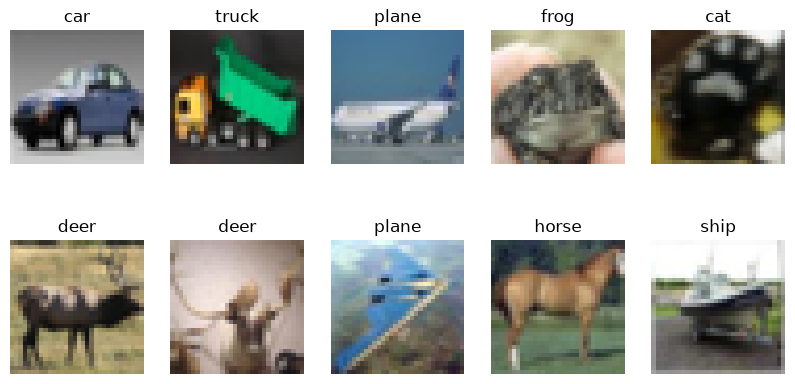

In [8]:
classes = (
    'plane',
    'car',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
)

images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 5, figsize=(10,5))

for i, ax in enumerate(axes.flat):

    img = images[i] / 2 + 0.5
    img = img.permute(1, 2, 0)

    ax.imshow(img)
    ax.set_title(classes[labels[i]])
    ax.axis('off')

plt.show()

In [9]:
class VGGMini(nn.Module):

    def __init__(self):
        super(VGGMini, self).__init__()

        self.features = nn.Sequential(

            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [10]:
model = VGGMini().to(device)

print(model)

VGGMini(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU()
    (7): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU()
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU()
    (12): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU()
    (14): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bias=True)
    (2): ReLU()
    (3)

In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

print("Loss function and optimizer initialized.")

Loss function and optimizer initialized.


In [12]:
epochs = 5

train_losses = []
val_losses = []

for epoch in range(epochs):

    # Training
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_loss = running_loss / len(train_loader)

    train_acc = 100 * correct / total

    train_losses.append(train_loss)

    # Validation
    model.eval()

    val_loss = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_loss += loss.item()

    val_loss /= len(val_loader)

    val_losses.append(val_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.2f}% "
        f"Val Loss: {val_loss:.4f}"
    )

Epoch [1/5] Train Loss: 1.7343 Train Acc: 34.95% Val Loss: 1.3541
Epoch [2/5] Train Loss: 1.2974 Train Acc: 53.19% Val Loss: 1.0832
Epoch [3/5] Train Loss: 1.0606 Train Acc: 62.54% Val Loss: 0.9268
Epoch [4/5] Train Loss: 0.9177 Train Acc: 67.81% Val Loss: 0.8363
Epoch [5/5] Train Loss: 0.8110 Train Acc: 71.50% Val Loss: 0.8245


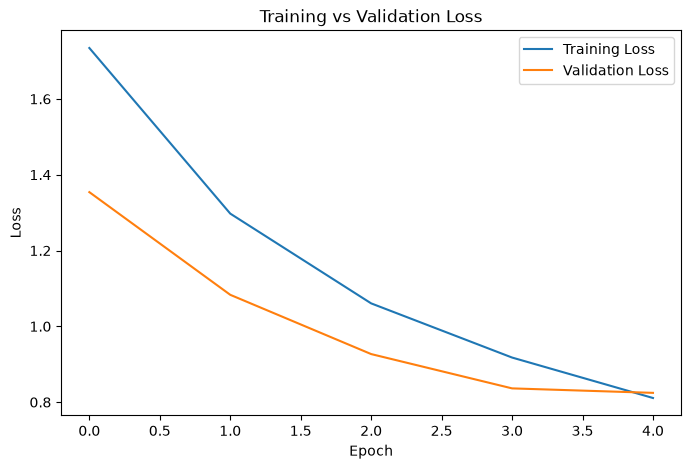

In [13]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [14]:
model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predicted = outputs.max(1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

test_accuracy = 100 * correct / total

print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Accuracy: 71.28%


## Architecture Explanation

This VGG-inspired CNN consists of three convolutional blocks that progressively learn more complex image features. Each block uses 3×3 convolutional filters followed by ReLU activation and MaxPooling. The number of filters increases from 32 to 128, allowing the network to capture richer feature representations. MaxPooling reduces spatial dimensions and computational cost. A fully connected classifier with dropout is used to improve generalization and reduce overfitting. This design follows the key principles of the VGG architecture while remaining lightweight for CIFAR-10 classification.